In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 60


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

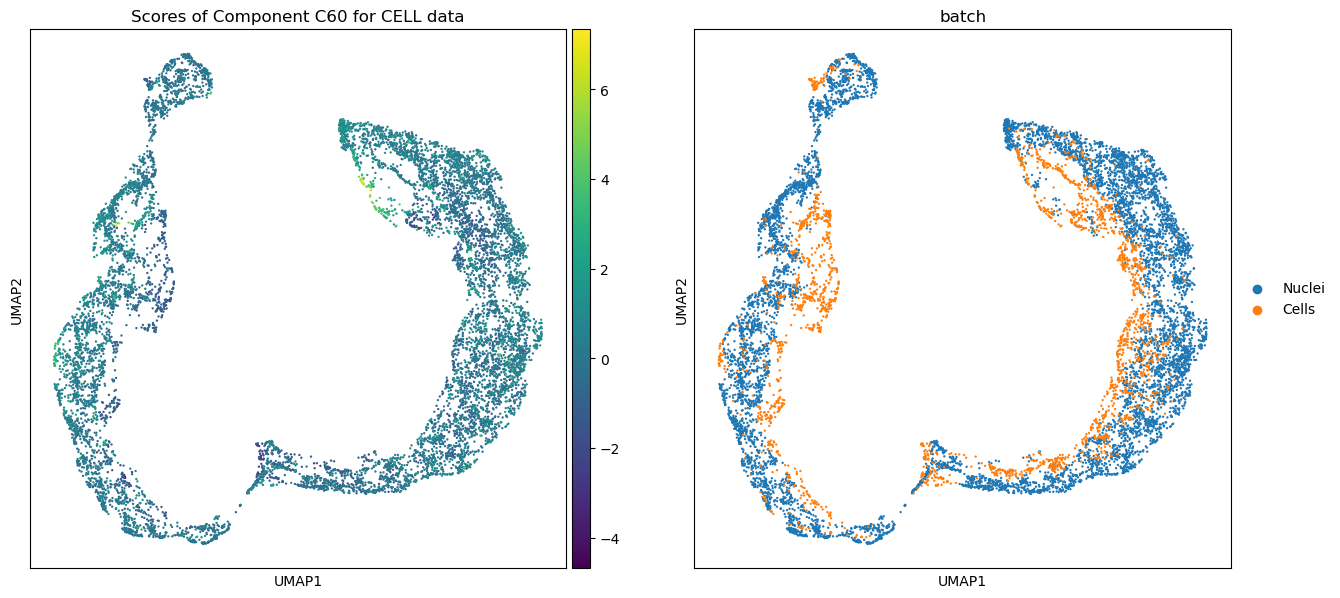

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

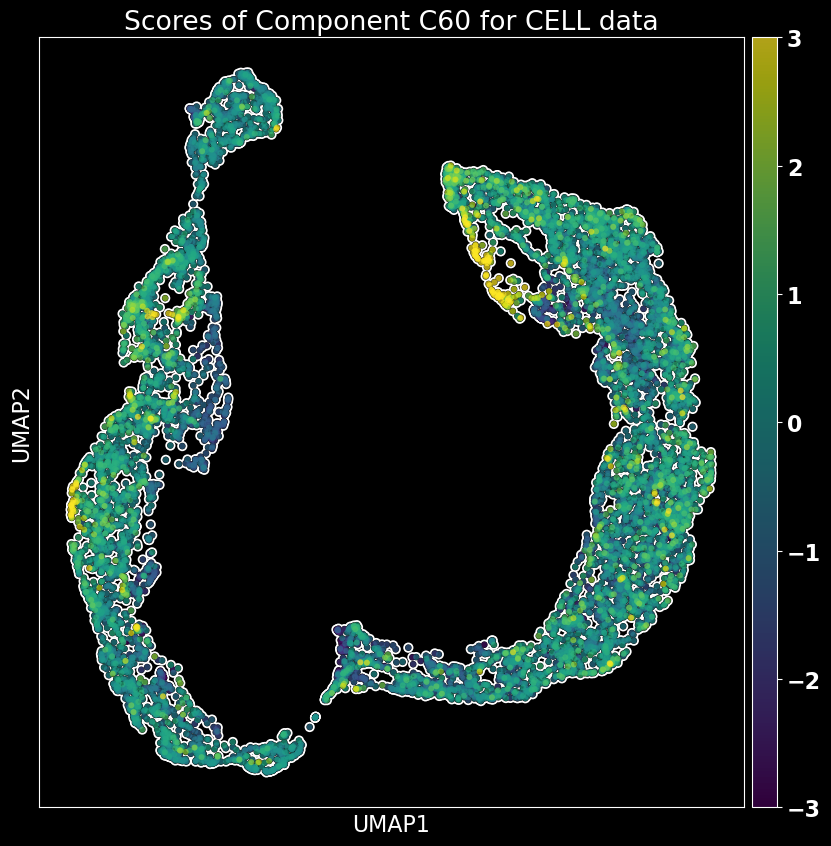

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

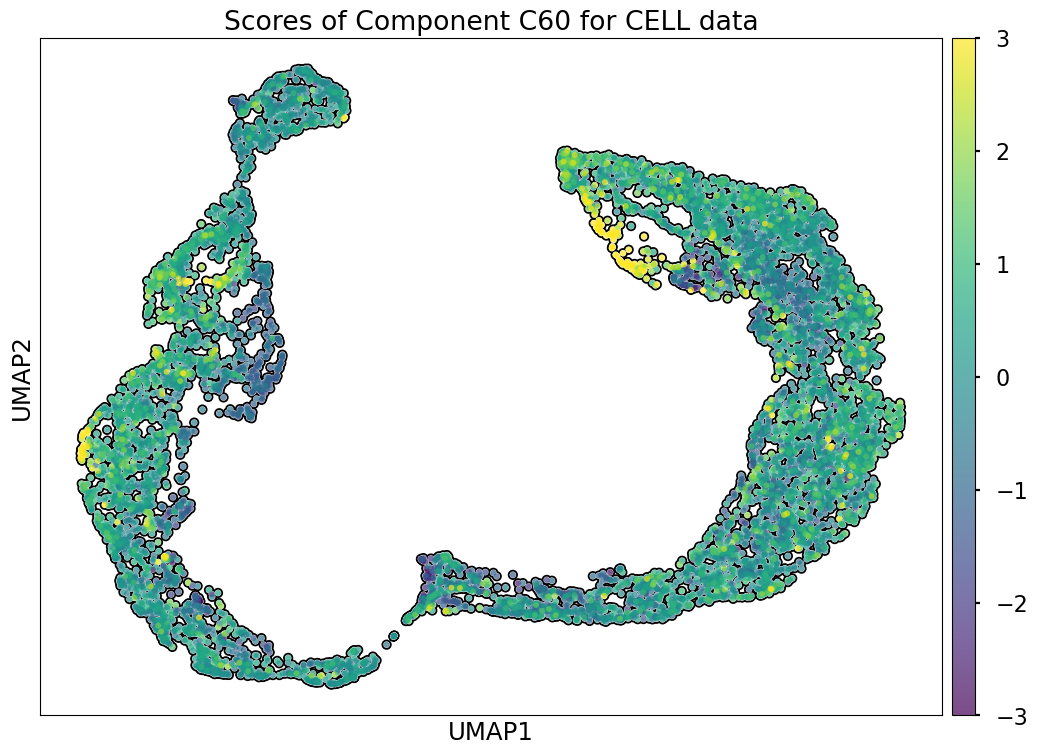

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

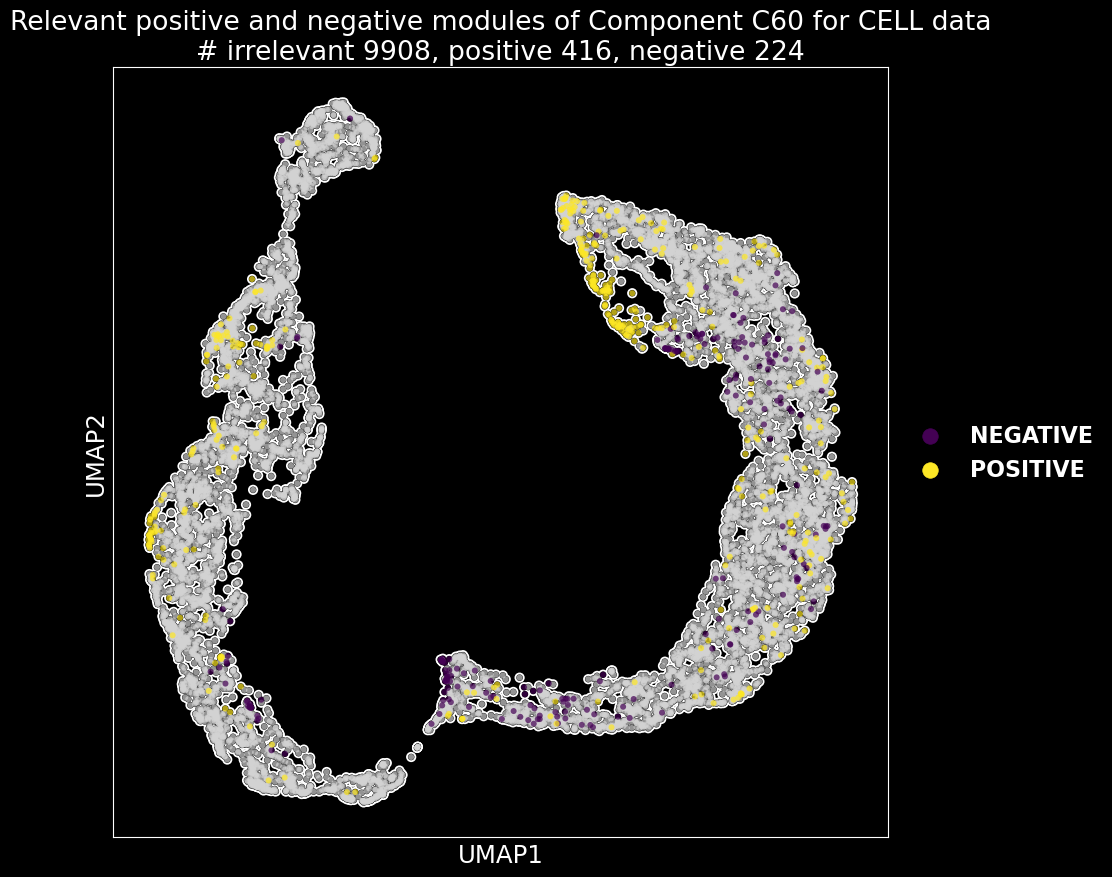

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

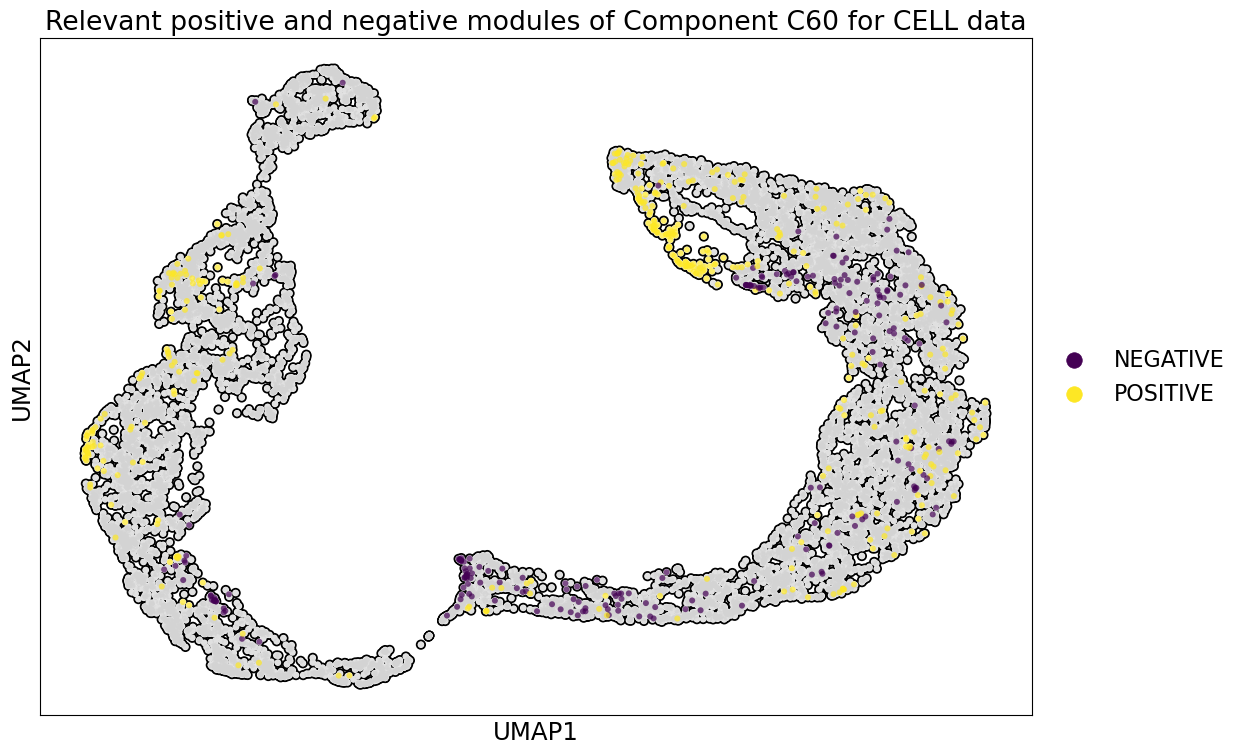

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 2.1842263636363635 var: 0.8408803389266962
Positive scores cells  - mean: 3.0626907729468607 var: 1.0670851140252504


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.7713836607142857 var: 0.25338151865952324
Negative scores cells  - mean: -2.6208831249999998 var: 0.576490949837635


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=30.5423759116605, pvalue=5.429589460923321e-188)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-35.49566214589376, pvalue=6.988669525923472e-249)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C60', ylabel='Count'>

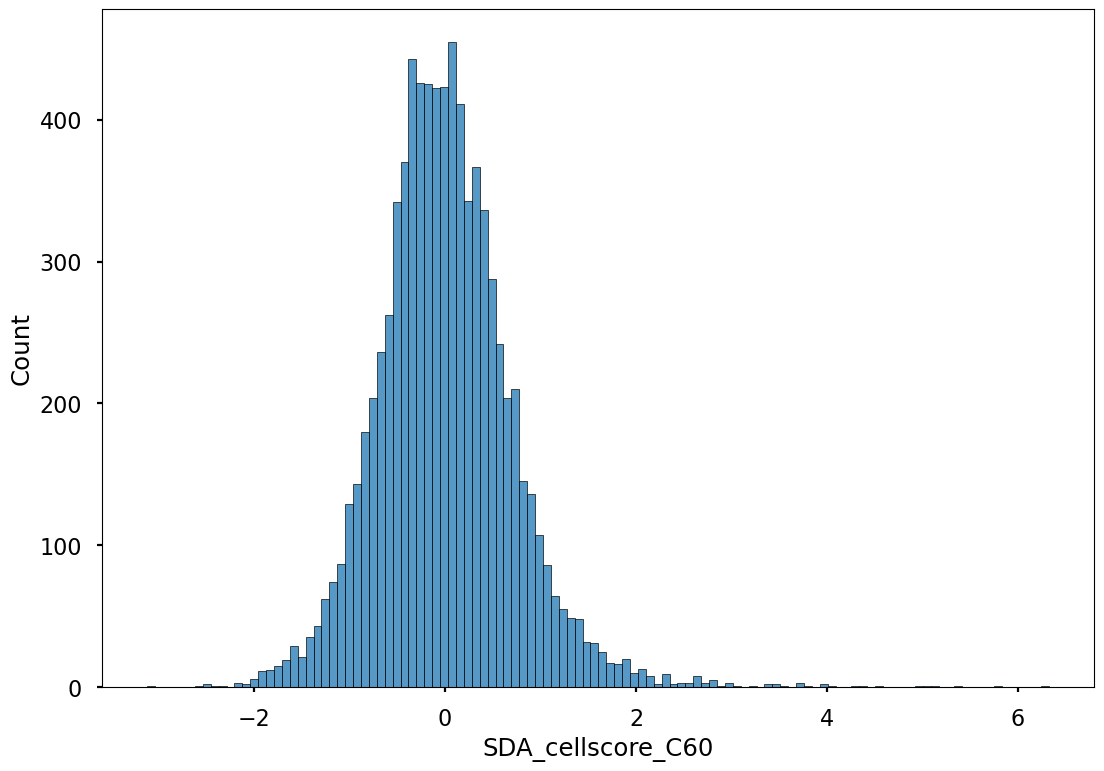

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C60', ylabel='Count'>

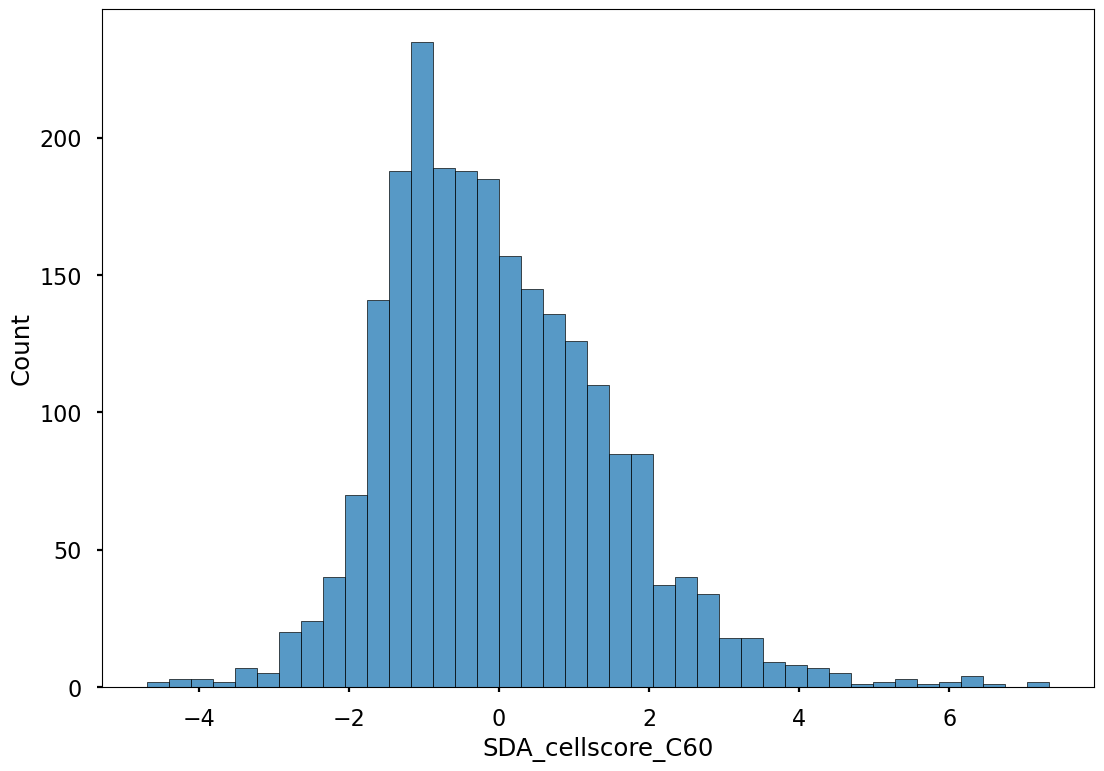

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C60: 966


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

GNB1
MMEL1
ACTRT2
CEP104
CHD5
RPL22
ENO1
VPS13D
FHAD1
PLEKHM2
CAPZB
EIF4G3
LUZP1
RPL11
ZNF683
PIGV
WASF2
AZIN2
PHC2
HMGB4
TEKT2
STK40
MRPS15
DNALI1
MTF1
AKIRIN1
CAP1
TMCO2
SLFNL1
HIVEP3
YBX1
CDC20
KIF2C
RPS8
LOC104007871
NSUN4
TEX38
SPATA6
TTC39A
NRDC
MROH7
LOC742772
HOOK1
JAK1
C1H1orf141
ERICH3
ASB17
SSX2IP
SH3GLB1
RPL5
LOC107967559
GSTM3
UBL4B
ATP5PB
DDX20
PPM1J
CSDE1
FAM46C
SPAG17
PHGDH
PLEKHO1
OAZ3
S100A10
SMCP
LELP1
GATAD2B
RPS27
UBAP2L
MTX1
ISG20L2
CFAP45
KLHDC9
SPATA46
MAEL
DCAF6
TEX35
CEP350
GLUL
LAMC1
ETNK2
LEMD1
MAPKAPK2
CD55
LOC745816
FAM71A
ESRRG
SPATA17
CCDC185
LOC112206648
LOC107970640
RBM34
LGALS8
CEP170
C1H1orf100
SCCPDH
ACP1
TRAPPC12
DCDC2C
MBOAT2
LPIN1
MAPRE3
AGBL5
ABHD1
PRR30
PPM1G
C2AH2orf16
DHX57
MTA3
PRKCE
TTC7A
GTF2A1L
PSME4
FAM161A
EHBP1
ANKRD53
RAB11FIP5
CCT7
HK2
RNF181
IMMT
TEX37
TEKT4
LOC741879
VWA3B
TSGA10
CFAP221
TEX51
CCNT2
KIF5C
STAM2
MARCH7
GORASP2
OLA1
PLEKHA3
PDE1A
INPP1
STAT4
SPATS2L
BZW1
ALS2CR12
C2CD6
MAP2
RPL37A
TNP1
ARPC2
LOC100612604
RETREG2
TUBA

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C60: 718


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

MRPL20
CAMTA1
CENPS
LOC107974981
MINOS1
SRSF10
STMN1
CATSPER4
ATP5IF1
PTP4A2
ZMYM1
TRAPPC3
MYCBP
RLF
EBNA1BP2
FAAH
OSBPL9
HSPB11
USP1
SERBP1
ACADM
RPF1
GNG5
WDR63
LOC741368
TAF13
LOC107968074
LOC112204994
LOC100614375
PHTF1
RBM8A
C1H1orf56
KRTCAP2
ATF6
LOC107969148
TIPRL
SUCO
TEX50
XPR1
SHCBP1L
LOC107969752
SLC30A1
CENPF
RRP15
MIA3
LOC107970358
SRP9
ARID4B
LOC107970667
COX20
EFCAB2
ZNF670
ALKAL2
LOC104004841
TTC32
PFN4
FAM228A
CCDC121
MRPL33
PPP1CB
TTC27
GPATCH11
CEBPZOS
SRSF7
GEMIN6
RPS27A
CCDC88A
CFAP36
LOC107973474
USP34
GMCL1
SNRNP27
PAIP2B
TPRKB
CTNNA2
USP39
CHMP3
CHCHD5
ANAPC1
LOC112208191
FER1L5
COA5
LOC112208197
DBI
TSN
WDR33
PLEKHB2
MZT2B
UBXN4
MMADHC
LOC107973810
KCNH7
GALNT3
DHRS9
BBS5
PHOSPHO2
ERICH2
HAT1
SCRN3
HNRNPA3
FKBP7
PPP1R1C
FSIP2
ORMDL1
SF3B1
C2BH2orf69
SGO2
NDUFB3
SUMO1
ABCB6
DNAJB2
OBSL1
LOC459972
ACSL3
LOC101059252
COPS9
LOC749543
TRNT1
RAF1
CCDC174
METTL6
OXNAD1
NKIRAS1
RBMS3
DYNC1LI1
KRBOX1
KIAA1143
KIF9
TMA7
IP6K2
MANF
TEX264
GLT8D1
SPCS1
ERC2
CCDC66
ARF4
C3H

#### Cells scores by cluster

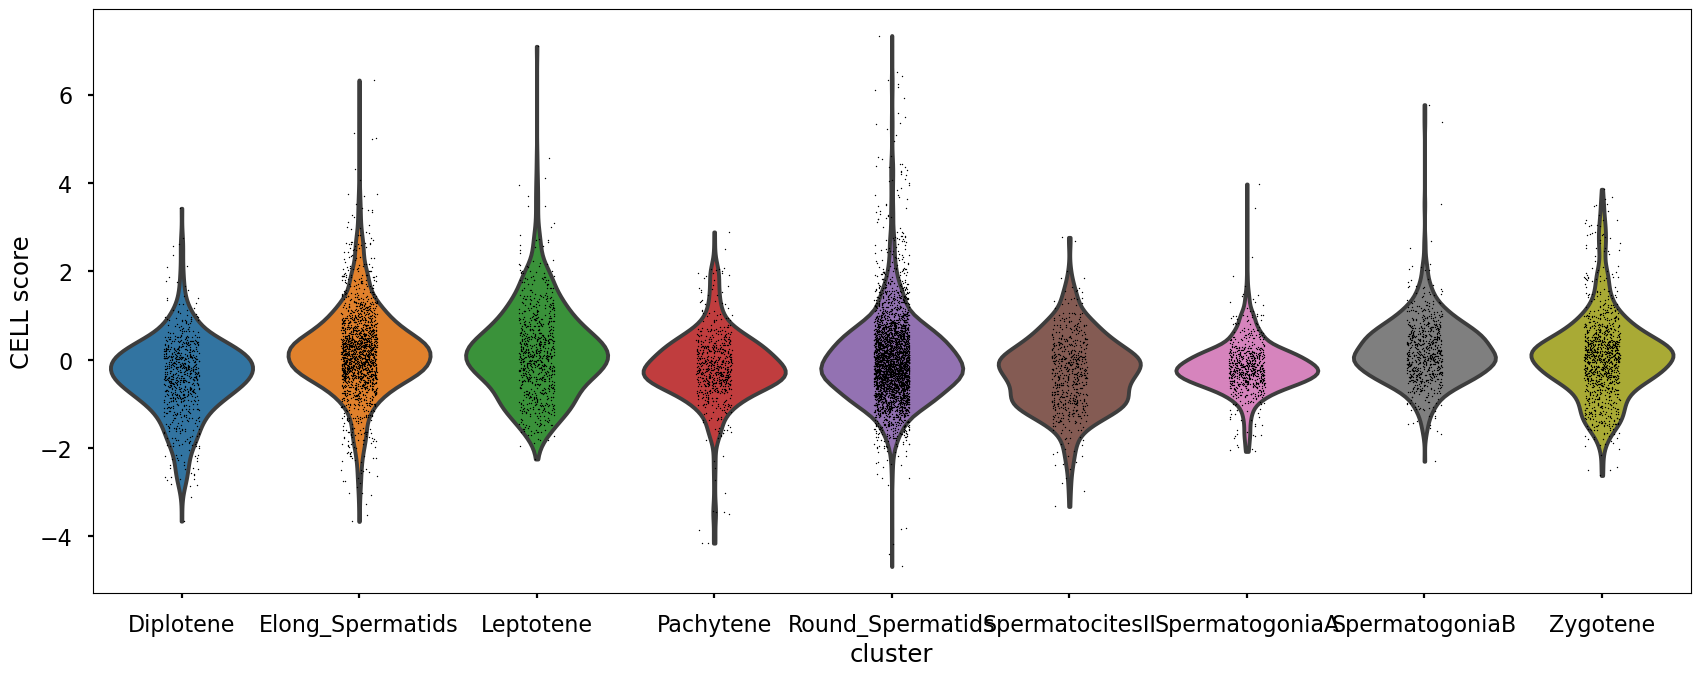

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

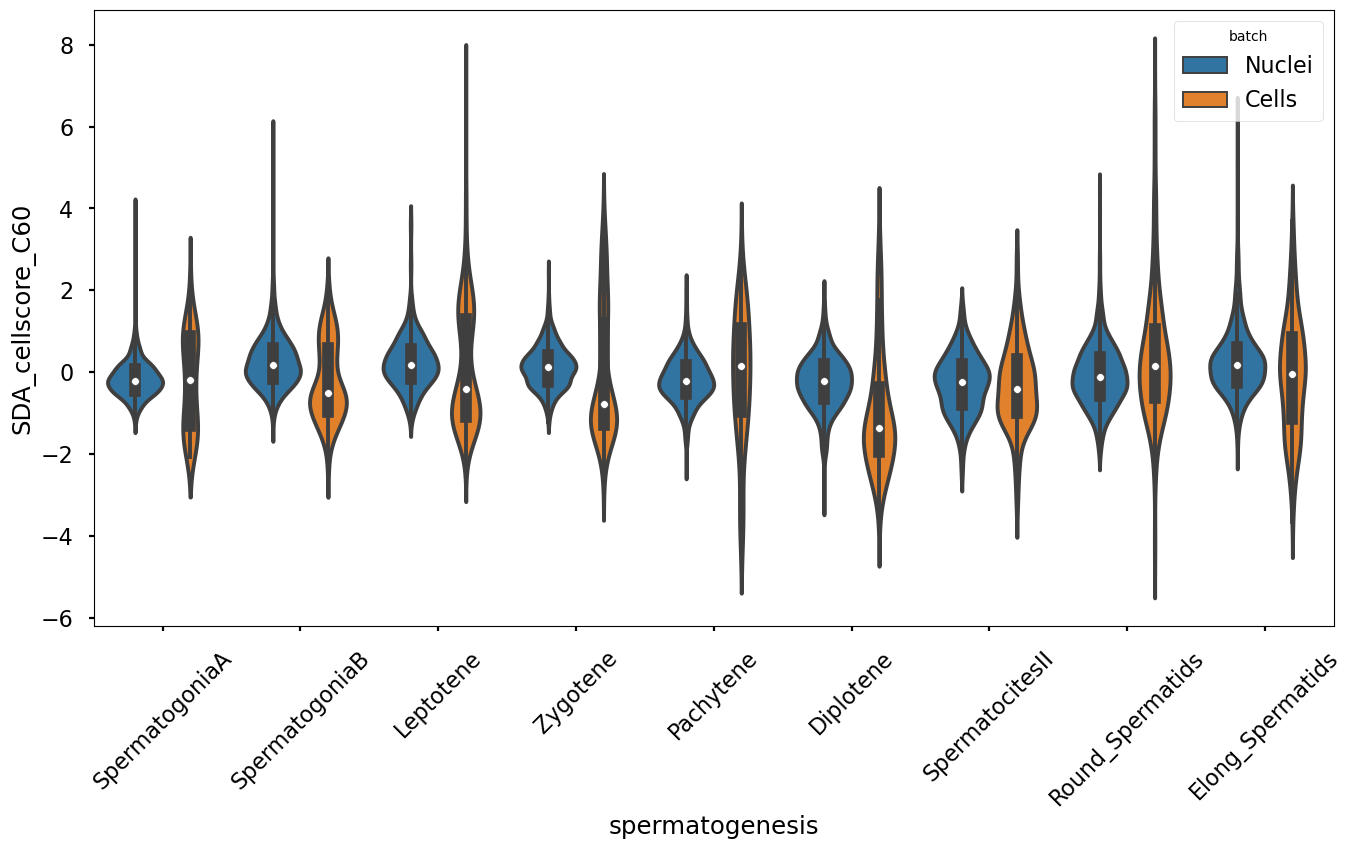

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C60')

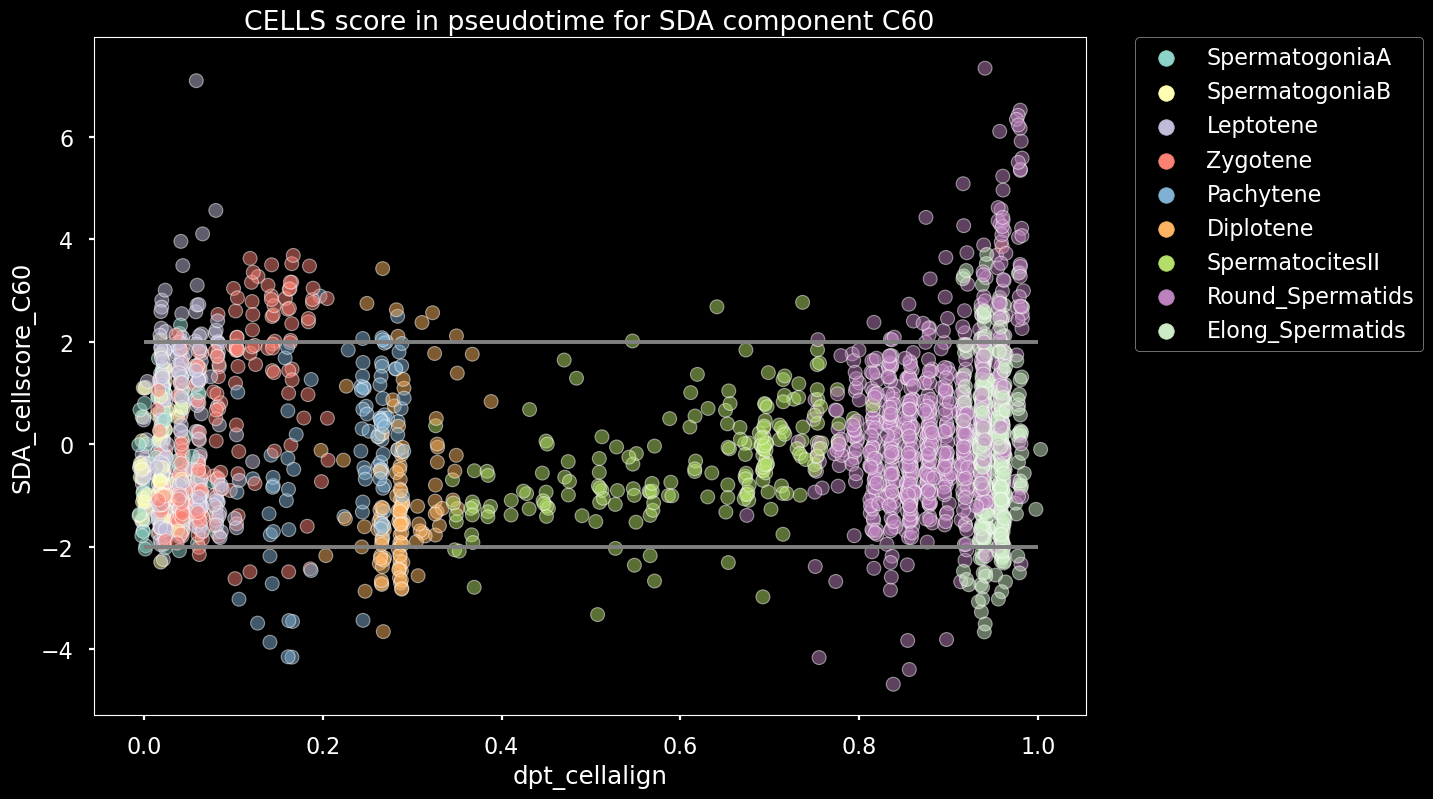

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C60')

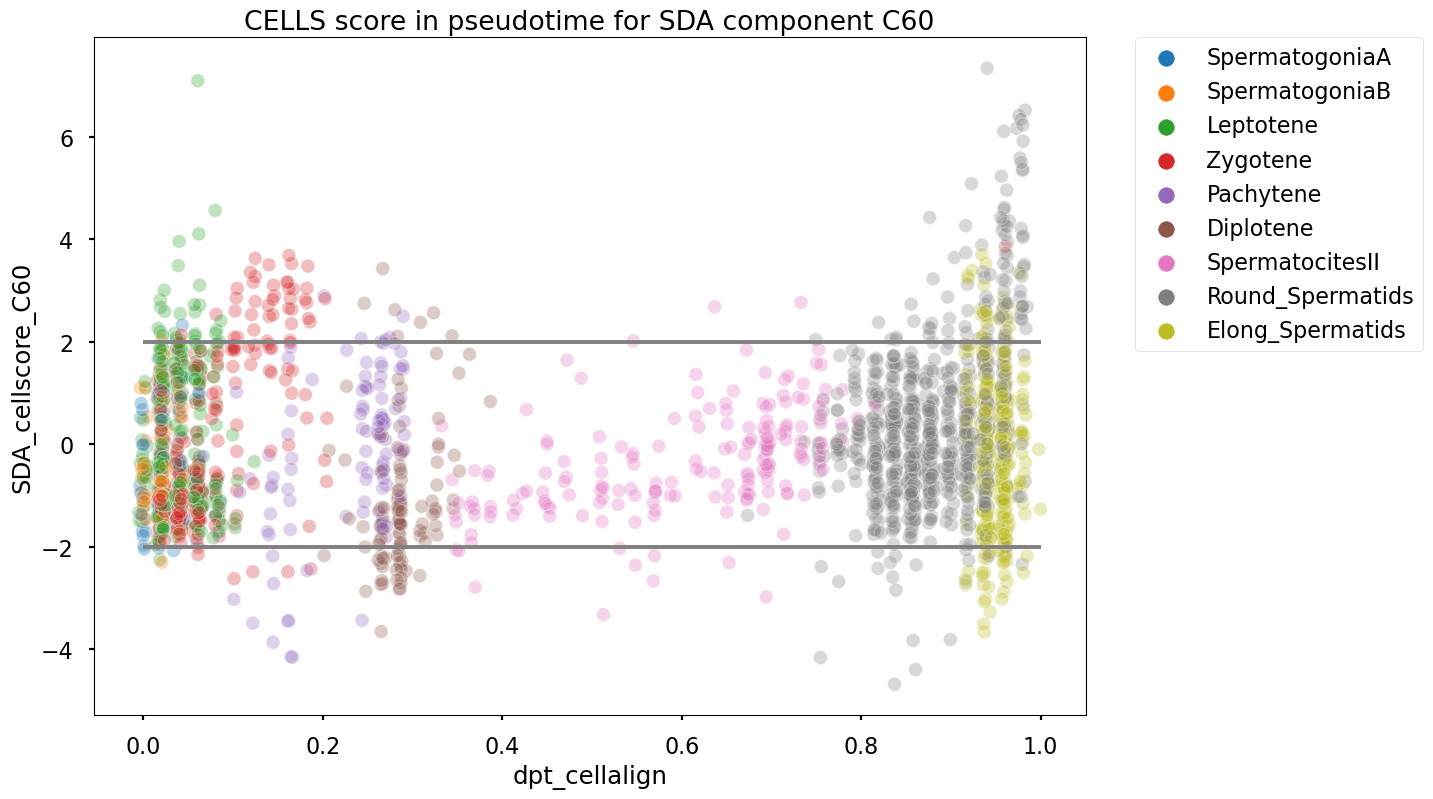

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C60')

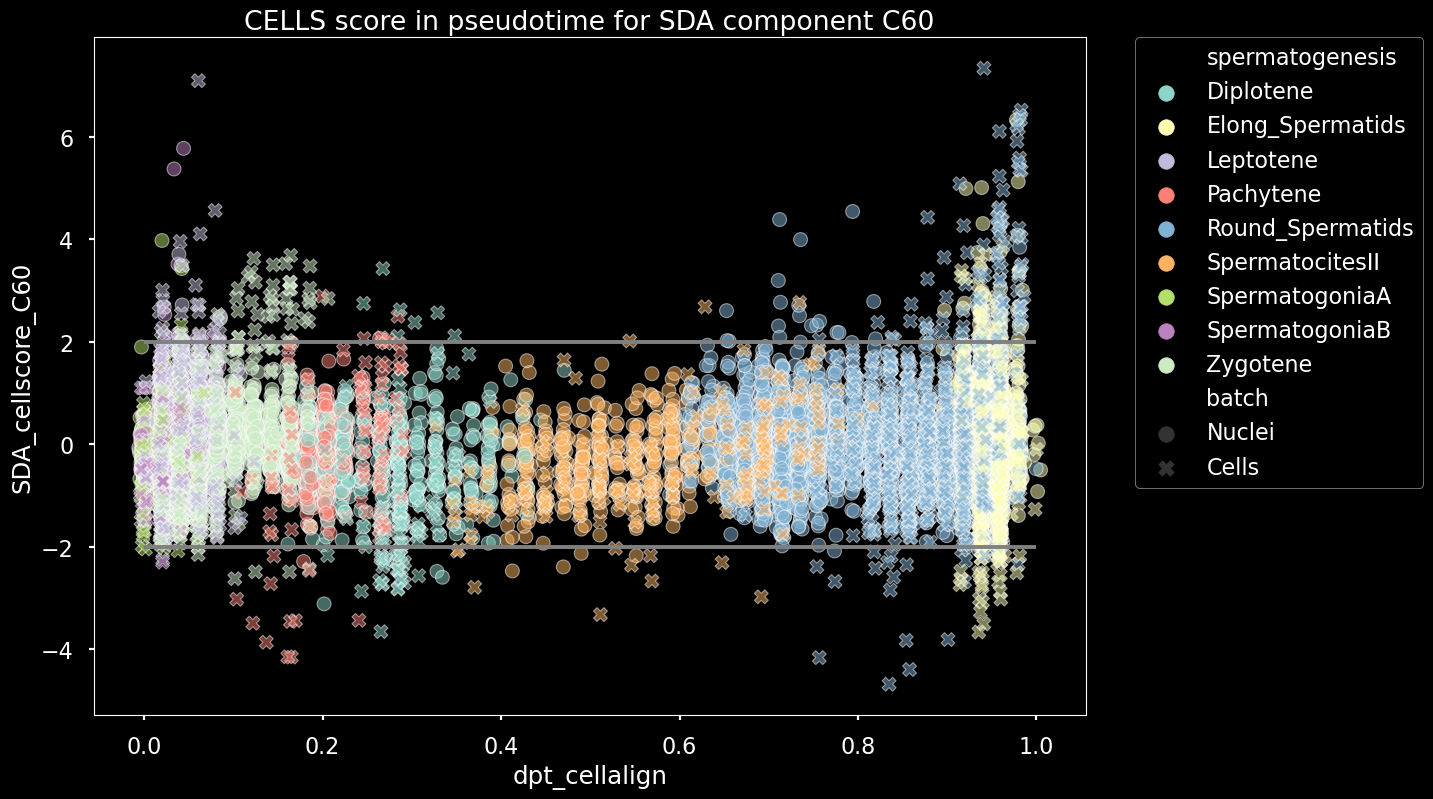

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C60')

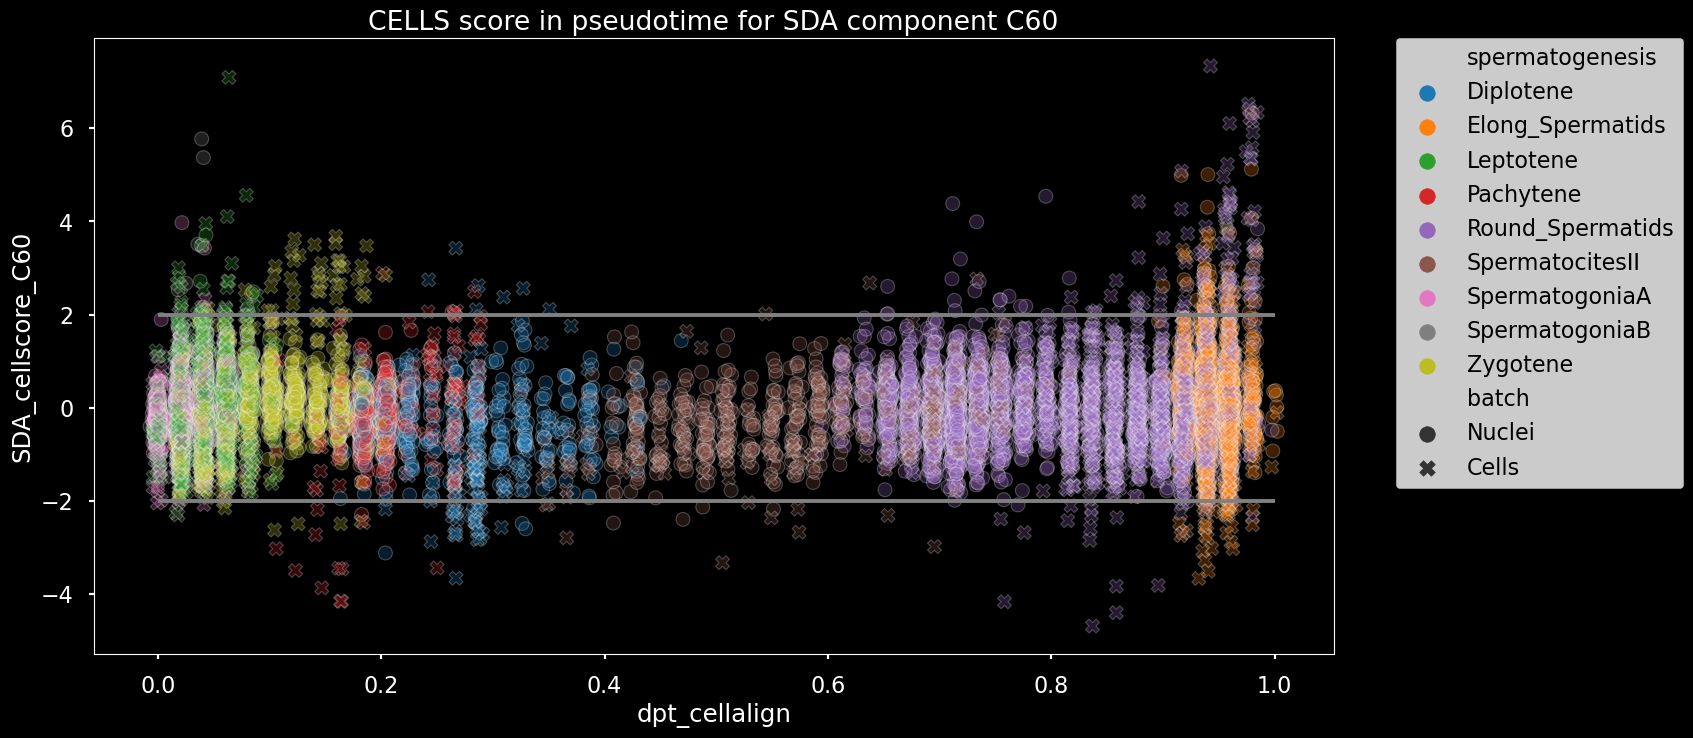

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,57/158,9.089998e-35,2.372489e-32,0,0,11.754632,921.366881,RPL4;RPL5;RPL30;MRPS15;RPL3;RPL32;RPL34;RPLP1;...
1,KEGG_2021_Human,Coronavirus disease,59/232,1.161692e-26,1.516008e-24,0,0,7.091912,423.510084,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPLP0;R...
2,KEGG_2021_Human,RNA transport,28/186,8.715640e-08,7.582607e-06,0,0,3.566220,57.970901,EIF4A1;DDX20;GLE1;FXR1;NUP88;EIF4E;RAE1;RPP38;...
261,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),36/52,1.098549e-35,1.559940e-33,0,0,46.011290,3703.747276,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPL12;R...
262,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),36/52,1.098549e-35,1.559940e-33,0,0,46.011290,3703.747276,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPL12;R...
263,GO_Cellular_Component_2023,Ribosome (GO:0005840),26/61,1.054036e-18,9.978203e-17,0,0,15.014407,621.504957,RPL30;RPL32;RPL11;RPL10A;RPL8;RPL9;RPL7A;RPL18...
264,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),21/41,1.999523e-17,1.419662e-15,0,0,21.126667,812.342258,RPS9;RPS8;RPS5;RPS6;RPSA;RPS15;RPS26;RPS14;RPS...
265,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),21/42,3.818775e-17,2.169064e-15,0,0,20.119577,760.600818,RPS9;RPS8;RPS5;RPS6;RPSA;RPS15;RPS26;RPS14;RPS...
266,GO_Cellular_Component_2023,Polysomal Ribosome (GO:0042788),15/28,3.386820e-13,1.603095e-11,0,0,23.078136,662.659026,RPL30;RPL32;RPL11;RPL10A;RPL8;RPS26;RPL7A;RPL1...
267,GO_Cellular_Component_2023,Nucleus (GO:0005634),307/4487,4.241695e-12,1.720916e-10,0,0,1.655465,43.350112,RPL4;JPT1;RPL5;EIF4A1;RPL30;TES;RPL3;CCNI;HDAC...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,57/158,2.372489e-32,11.754632,921.366881,RPL4;RPL5;RPL30;MRPS15;RPL3;RPL32;RPL34;RPLP1;...,60P,Yes,416
1,KEGG_2021_Human,Coronavirus disease,59/232,1.516008e-24,7.091912,423.510084,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPLP0;R...,60P,Yes,416
2,KEGG_2021_Human,RNA transport,28/186,7.582607e-06,3.566220,57.970901,EIF4A1;DDX20;GLE1;FXR1;NUP88;EIF4E;RAE1;RPP38;...,60P,Yes,416
261,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),36/52,1.559940e-33,46.011290,3703.747276,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPL12;R...,60P,Yes,416
262,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),36/52,1.559940e-33,46.011290,3703.747276,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPL12;R...,60P,Yes,416
263,GO_Cellular_Component_2023,Ribosome (GO:0005840),26/61,9.978203e-17,15.014407,621.504957,RPL30;RPL32;RPL11;RPL10A;RPL8;RPL9;RPL7A;RPL18...,60P,Yes,416
264,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),21/41,1.419662e-15,21.126667,812.342258,RPS9;RPS8;RPS5;RPS6;RPSA;RPS15;RPS26;RPS14;RPS...,60P,Yes,416
265,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),21/42,2.169064e-15,20.119577,760.600818,RPS9;RPS8;RPS5;RPS6;RPSA;RPS15;RPS26;RPS14;RPS...,60P,Yes,416
266,GO_Cellular_Component_2023,Polysomal Ribosome (GO:0042788),15/28,1.603095e-11,23.078136,662.659026,RPL30;RPL32;RPL11;RPL10A;RPL8;RPS26;RPL7A;RPL1...,60P,Yes,416
267,GO_Cellular_Component_2023,Nucleus (GO:0005634),307/4487,1.720916e-10,1.655465,43.350112,RPL4;JPT1;RPL5;EIF4A1;RPL30;TES;RPL3;CCNI;HDAC...,60P,Yes,416


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Protein export,13/23,1.213919e-13,2.694901e-11,0,0,35.537021,1056.862202,SRP19;HSPA5;SRP14;SRP9;IMMP1L;SPCS3;SPCS1;SEC6...
1,KEGG_2021_Human,Parkinson disease,33/249,9.901663e-11,1.099085e-08,0,0,4.252352,97.956046,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;NDUFB5;NDUFB...
2,KEGG_2021_Human,Amyotrophic lateral sclerosis,39/364,1.219916e-09,9.027379e-08,0,0,3.350280,68.762764,PSMD12;NDUFB8;NUP107;UQCRB;NDUFB6;PSMD13;DNAH8...
3,KEGG_2021_Human,Oxidative phosphorylation,22/133,2.087998e-09,1.158839e-07,0,0,5.459278,109.114922,ATP5PF;NDUFA8;NDUFB8;NDUFA7;UQCRB;NDUFB6;NDUFA...
4,KEGG_2021_Human,Huntington disease,34/306,5.647722e-09,2.507588e-07,0,0,3.474050,65.979199,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;DNAH8;NDUFB5...
5,KEGG_2021_Human,Prion disease,31/273,1.598889e-08,5.915888e-07,0,0,3.550230,63.731506,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;NDUFB5;NDUFB...
6,KEGG_2021_Human,Thermogenesis,27/232,8.096114e-08,2.567625e-06,0,0,3.636151,59.375791,NDUFB8;UQCRB;NDUFB6;NDUFB5;NDUFB3;PRKAG2;COX7A...
7,KEGG_2021_Human,Non-alcoholic fatty liver disease,21/155,1.734793e-07,4.814051e-06,0,0,4.305317,67.021763,NDUFA8;NDUFB8;NDUFA7;UQCRB;NDUFB6;NDUFA5;NDUFB...
8,KEGG_2021_Human,Alzheimer disease,33/369,1.541063e-06,3.801288e-05,0,0,2.716449,36.354347,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;NDUFB5;NDUFB...
9,KEGG_2021_Human,Pathways of neurodegeneration,38/475,3.795752e-06,8.426570e-05,0,0,2.409847,30.078808,NDUFB8;PSMD12;UQCRB;NDUFB6;NDUFB5;PSMD13;DNAH8...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Protein export,13/23,2.694901e-11,35.537021,1056.862202,SRP19;HSPA5;SRP14;SRP9;IMMP1L;SPCS3;SPCS1;SEC6...,60N,Yes,224
1,KEGG_2021_Human,Parkinson disease,33/249,1.099085e-08,4.252352,97.956046,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;NDUFB5;NDUFB...,60N,Yes,224
2,KEGG_2021_Human,Amyotrophic lateral sclerosis,39/364,9.027379e-08,3.350280,68.762764,PSMD12;NDUFB8;NUP107;UQCRB;NDUFB6;PSMD13;DNAH8...,60N,Yes,224
3,KEGG_2021_Human,Oxidative phosphorylation,22/133,1.158839e-07,5.459278,109.114922,ATP5PF;NDUFA8;NDUFB8;NDUFA7;UQCRB;NDUFB6;NDUFA...,60N,Yes,224
4,KEGG_2021_Human,Huntington disease,34/306,2.507588e-07,3.474050,65.979199,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;DNAH8;NDUFB5...,60N,Yes,224
5,KEGG_2021_Human,Prion disease,31/273,5.915888e-07,3.550230,63.731506,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;NDUFB5;NDUFB...,60N,Yes,224
6,KEGG_2021_Human,Thermogenesis,27/232,2.567625e-06,3.636151,59.375791,NDUFB8;UQCRB;NDUFB6;NDUFB5;NDUFB3;PRKAG2;COX7A...,60N,Yes,224
7,KEGG_2021_Human,Non-alcoholic fatty liver disease,21/155,4.814051e-06,4.305317,67.021763,NDUFA8;NDUFB8;NDUFA7;UQCRB;NDUFB6;NDUFA5;NDUFB...,60N,Yes,224
8,KEGG_2021_Human,Alzheimer disease,33/369,3.801288e-05,2.716449,36.354347,PSMD12;NDUFB8;UQCRB;NDUFB6;PSMD13;NDUFB5;NDUFB...,60N,Yes,224
9,KEGG_2021_Human,Pathways of neurodegeneration,38/475,8.426570e-05,2.409847,30.078808,NDUFB8;PSMD12;UQCRB;NDUFB6;NDUFB5;PSMD13;DNAH8...,60N,Yes,224


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

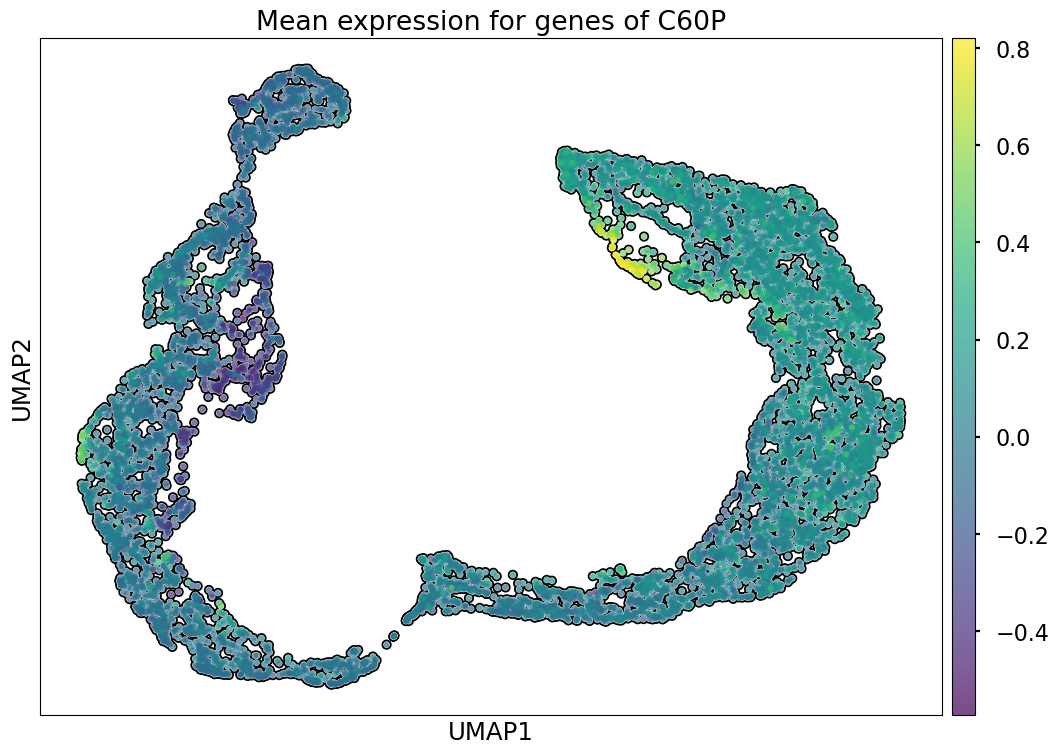

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

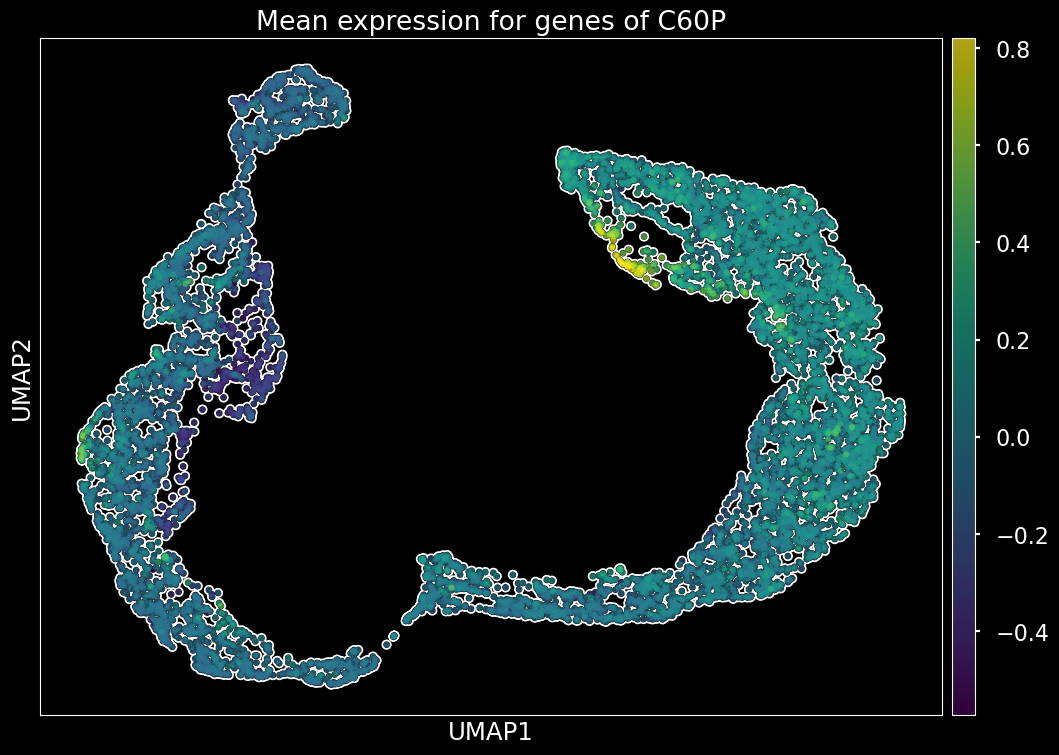

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

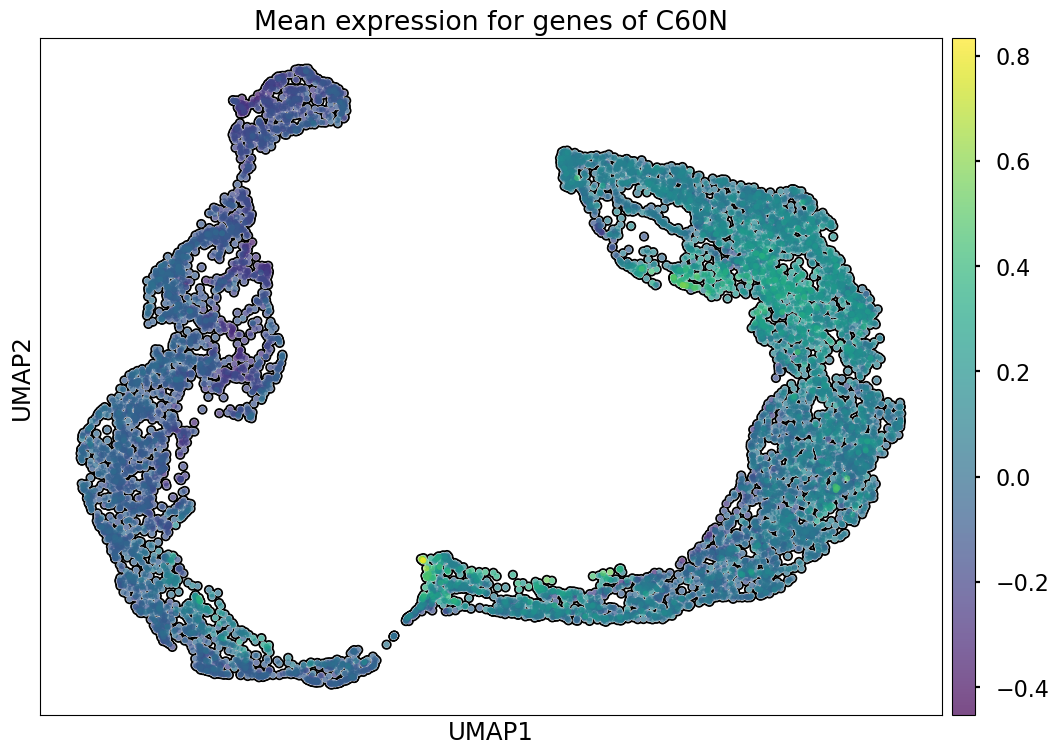

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

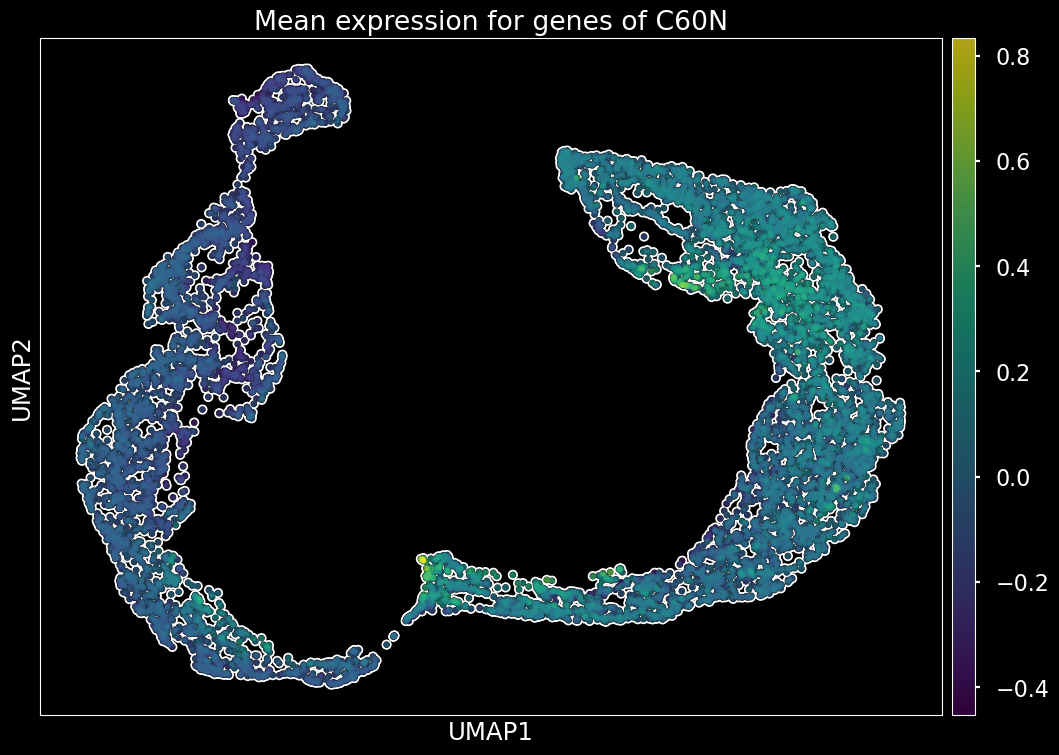

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)